# Appendix F — How macro conditions change the final allocation

This notebook displays the guarded PIT setting, the deployable setting from Appendix E. It reads saved macro states and saved allocation steps. It does not call a provider, rebuild a portfolio, or recalculate performance.

## How to read this appendix

- **Point in time (PIT)** means each rebalance uses only information available on that date.
- A **z-score** places a macro reading against its own history. Zero is the historical center; positive is above it and negative is below it.
- A **final weight change** is the target portfolio weight minus the HRP base weight. Positive adds weight; negative removes weight.
- **SWDA.L** is world equity, **XLK** is technology, **IAU** is gold, and **BIL** is the short-Treasury cash proxy.
- The scatterplots compare values from the same date. They are descriptive and non-causal.

The allocation heatmap uses the final weight change because it is the clearest portfolio result. The worked examples also show the intermediate exposure tilts and the Black-Litterman view input.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import struct
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap

EXPECTED_BUNDLE_SCHEMA = "canonical_guard_ablation_reports.v1"
EXPECTED_SOURCE_RUN_SCHEMA = "factor_guard_ablation_run.v1"
EXPECTED_PRODUCER = "scripts/build_tear_sheet.py"
EXPECTED_TABLE_SCHEMAS = {
    "tear_sheet_factor_guard_ablation_ext2026.parquet": "tear_sheet.factor_guard_ablation.v1",
    "factor_guard_ablation_equity_ext2026.parquet": "factor_guard_ablation.equity.v1",
    "factor_guard_ablation_panel_ext2026.parquet": "factor_guard_ablation.panel.v1",
}
CONFIG_IDS = (
    "factor_pit_ext2026",
    "factor_pit_unguarded_diagnostic_ext2026",
    "factor_nonpit_diagnostic_ext2026",
    "factor_nonpit_unguarded_diagnostic_ext2026",
)
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
SECONDARY = "#52514e"
GRID = "#e1e0d9"


def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / ".git").exists():
            return candidate
    raise RuntimeError("Repository root not found; run this notebook inside the repository.")


IMPORT_REPO_ROOT = find_repo_root(Path.cwd())
if str(IMPORT_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(IMPORT_REPO_ROOT))
from macro_framework.appendix_presentation import markdown_lines


def resolve_repo_path(repo_root: Path, raw: str | Path, label: str) -> Path:
    candidate = Path(raw).expanduser()
    if not candidate.is_absolute():
        candidate = repo_root / candidate
    resolved = candidate.resolve()
    try:
        resolved.relative_to(repo_root)
    except ValueError as exc:
        raise ValueError(f"{label} must remain inside repository root {repo_root}: {resolved}") from exc
    return resolved


def repo_relative_path(repo_root: Path, path: Path, label: str) -> str:
    try:
        return path.resolve().relative_to(repo_root.resolve()).as_posix()
    except ValueError as exc:
        raise ValueError(f"{label} must remain inside repository root {repo_root}: {path}") from exc


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def completed_manifest_sha256(marker_path: Path) -> str:
    lines = marker_path.read_text(encoding="utf-8").splitlines()
    if len(lines) != 1 or not lines[0].startswith("manifest_sha256="):
        raise ValueError(f"{marker_path} must equal one manifest_sha256=<64 hex> line")
    value = lines[0].removeprefix("manifest_sha256=")
    if lines[0] != f"manifest_sha256={value}" or len(value) != 64 or any(ch not in "0123456789abcdef" for ch in value):
        raise ValueError(f"Malformed exact completed-marker manifest SHA in {marker_path}")
    return value


def require_column(frame: pd.DataFrame, candidates: tuple[str, ...], context: str) -> str:
    matches = [name for name in candidates if name in frame.columns]
    if not matches:
        raise ValueError(f"{context} requires one of columns {candidates}; observed={list(frame.columns)}")
    return matches[0]


def table_entry(manifest: dict, filename: str) -> tuple[str, dict]:
    inventory = manifest.get("tables")
    if not isinstance(inventory, dict):
        raise ValueError("Bundle manifest requires a tables inventory mapping")
    matches = [(name, meta) for name, meta in inventory.items() if isinstance(meta, dict) and Path(str(meta.get("file", ""))).name == filename]
    if len(matches) != 1:
        raise ValueError(f"Manifest must inventory {filename} exactly once; matches={len(matches)}")
    return matches[0]


def validate_frame_inventory(repo_root: Path, frame: pd.DataFrame, path: Path, meta: dict, context: str) -> dict:
    observed_sha = sha256_file(path)
    if observed_sha != meta.get("sha256"):
        raise ValueError(f"{context} hash mismatch: manifest={meta.get('sha256')} observed={observed_sha}")
    if int(meta.get("rows", -1)) != len(frame):
        raise ValueError(f"{context} row-count mismatch: manifest={meta.get('rows')} observed={len(frame)}")
    expected_schema = EXPECTED_TABLE_SCHEMAS[path.name]
    schema = meta.get("schema", meta.get("schema_id"))
    if schema != expected_schema:
        raise ValueError(f"{context} schema mismatch: expected {expected_schema}, observed {schema}")
    return {"file": repo_relative_path(repo_root, path, context), "sha256": observed_sha, "rows": len(frame), "schema": expected_schema}


def validate_source_child_run_lineage(repo_root: Path, source_run_dir: Path, bundle_manifest: dict) -> dict:
    inputs = bundle_manifest.get("input_manifests")
    if not isinstance(inputs, dict) or set(inputs) != {"factor_guard_ablation_run"}:
        raise ValueError("Canonical bundle must pin exactly factor_guard_ablation_run")
    pinned = inputs["factor_guard_ablation_run"]
    manifest_path, marker_path = source_run_dir / "manifest.json", source_run_dir / "COMPLETED"
    if not manifest_path.is_file() or not marker_path.is_file():
        raise FileNotFoundError(f"Completed source guard-ablation run not found at {source_run_dir}")
    manifest_sha = sha256_file(manifest_path)
    if completed_manifest_sha256(marker_path) != manifest_sha:
        raise ValueError("Source child-run COMPLETED marker does not exactly bind manifest SHA")
    source_manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    if source_manifest.get("schema") != EXPECTED_SOURCE_RUN_SCHEMA or source_manifest.get("completed") is not True:
        raise ValueError(f"Source child run must be completed {EXPECTED_SOURCE_RUN_SCHEMA}")
    if (source_manifest.get("run_id"), manifest_sha) != (pinned.get("run_id"), pinned.get("manifest_sha256")):
        raise ValueError("Canonical bundle lineage diverges from source child-run identity/hash")
    parents = source_manifest.get("input_manifests")
    if not isinstance(parents, dict) or not {"factor_run", "market_snapshot"}.issubset(parents):
        raise ValueError("Source child run must pin parent Factor and market manifests")
    for role, identity_field in (("factor_run", "run_id"), ("market_snapshot", "snapshot_id")):
        declaration = parents[role]
        if not isinstance(declaration, dict) or not isinstance(declaration.get(identity_field), str) or len(str(declaration.get("manifest_sha256", ""))) != 64:
            raise ValueError(f"Source child-run parent lineage is malformed for {role}")
    source_files = source_manifest.get("files")
    source_artifacts = bundle_manifest.get("source_artifacts")
    if not isinstance(source_files, dict) or not isinstance(source_artifacts, dict) or not {"metric_records", "panel"}.issubset(source_artifacts):
        raise ValueError("Canonical bundle must hash-bind child metric-record and panel artifacts")
    for role, declaration in source_artifacts.items():
        matches = [entry for entry in source_files.values() if isinstance(entry, dict) and entry.get("file") == declaration.get("file")]
        source_path = (source_run_dir / str(declaration.get("file"))).resolve()
        try:
            source_path.relative_to(source_run_dir)
        except ValueError as exc:
            raise ValueError(f"Source artifact path escapes child run for {role}") from exc
        if len(matches) != 1 or matches[0].get("sha256") != declaration.get("sha256") or not source_path.is_file() or sha256_file(source_path) != declaration.get("sha256"):
            raise ValueError(f"Canonical source artifact lineage mismatch for {role}")
    return {
        "run_id": source_manifest["run_id"],
        "manifest_path": repo_relative_path(repo_root, manifest_path, "source child-run manifest"),
        "manifest_sha256": manifest_sha,
        "schema": source_manifest["schema"],
        "source_commit": source_manifest.get("source_commit"),
        "parent_manifests": parents,
    }


def validate_table_semantics(frames: dict[str, pd.DataFrame]) -> None:
    tear = frames["tear_sheet_factor_guard_ablation_ext2026.parquet"]
    equity = frames["factor_guard_ablation_equity_ext2026.parquet"]
    panel = frames["factor_guard_ablation_panel_ext2026.parquet"]
    if len(tear) != 21 or list(tear.get("row_order", ())) != list(range(21)):
        raise ValueError("Guard-ablation tear sheet must preserve the exact 21-row order")
    if set(tear.iloc[:12]["configuration"].astype(str)) != set(CONFIG_IDS):
        raise ValueError("Tear sheet must cover the exact four protocol cells")
    if tuple(equity.columns) != ("date", "configuration", "normalized_wealth", "drawdown", "relative_wealth", "relative_wealth_kind"):
        raise ValueError("Canonical equity table columns diverge")
    if set(panel["configuration"].astype(str)) != set(CONFIG_IDS):
        raise ValueError("Canonical panel must cover the exact four protocol cells")


def load_completed_bundle(repo_root: Path, bundle_dir: Path, source_run_dir: Path) -> tuple[dict, str, dict[str, pd.DataFrame], dict[str, dict], dict]:
    manifest_path, marker_path = bundle_dir / "manifest.json", bundle_dir / "COMPLETED"
    if not manifest_path.is_file() or not marker_path.is_file():
        raise FileNotFoundError(f"Completed guard-ablation bundle not found at {bundle_dir}")
    manifest_sha = sha256_file(manifest_path)
    if completed_manifest_sha256(marker_path) != manifest_sha:
        raise ValueError("Bundle COMPLETED marker does not exactly match manifest.json SHA-256")
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    if manifest.get("schema") != EXPECTED_BUNDLE_SCHEMA or manifest.get("completed") is not True or manifest.get("producer") != EXPECTED_PRODUCER:
        raise ValueError(f"Expected completed {EXPECTED_BUNDLE_SCHEMA} from {EXPECTED_PRODUCER}")
    source_child_run = validate_source_child_run_lineage(repo_root, source_run_dir, manifest)
    frames: dict[str, pd.DataFrame] = {}
    source_inventory: dict[str, dict] = {}
    for filename in EXPECTED_TABLE_SCHEMAS:
        _, meta = table_entry(manifest, filename)
        relative = Path(str(meta["file"]))
        path = (bundle_dir / relative).resolve()
        try:
            path.relative_to(bundle_dir)
        except ValueError as exc:
            raise ValueError(f"Manifest table path escapes bundle: {relative}") from exc
        frame = pd.read_parquet(path)
        source_inventory[filename] = validate_frame_inventory(repo_root, frame, path, meta, filename)
        frames[filename] = frame
    validate_table_semantics(frames)
    return manifest, manifest_sha, frames, source_inventory, source_child_run


def source_hash_snapshot(repo_root: Path, bundle_dir: Path, source_run_dir: Path, source_inventory: dict[str, dict], bundle_manifest: dict) -> dict[str, str]:
    snapshot = {
        "bundle/manifest.json": sha256_file(bundle_dir / "manifest.json"),
        "bundle/COMPLETED": sha256_file(bundle_dir / "COMPLETED"),
        "source_run/manifest.json": sha256_file(source_run_dir / "manifest.json"),
        "source_run/COMPLETED": sha256_file(source_run_dir / "COMPLETED"),
    }
    snapshot.update({f"table/{name}": sha256_file(repo_root / meta["file"]) for name, meta in source_inventory.items()})
    for role, declaration in bundle_manifest["source_artifacts"].items():
        snapshot[f"source_artifact/{role}"] = sha256_file(source_run_dir / declaration["file"])
    return snapshot


def assert_sources_unchanged(repo_root: Path, bundle_dir: Path, source_run_dir: Path, source_inventory: dict[str, dict], bundle_manifest: dict, before: dict[str, str]) -> None:
    if source_hash_snapshot(repo_root, bundle_dir, source_run_dir, source_inventory, bundle_manifest) != before:
        raise RuntimeError("Canonical guard-ablation inputs changed during presentation rendering")


def png_dimensions(path: Path) -> tuple[int, int]:
    with path.open("rb") as handle:
        header = handle.read(24)
    if len(header) != 24 or header[:8] != b"\x89PNG\r\n\x1a\n":
        raise ValueError(f"Not a PNG: {path}")
    return struct.unpack(">II", header[16:24])


def build_output_inventory(output_dir: Path, figure_names: tuple[str, ...]) -> dict[str, dict]:
    inventory: dict[str, dict] = {}
    for name in figure_names:
        path = output_dir / name
        width, height = png_dimensions(path)
        inventory[name] = {"file": name, "sha256": sha256_file(path), "bytes": path.stat().st_size, "width_px": width, "height_px": height, "media_type": "image/png"}
    return inventory


def write_presentation_manifest(*, repo_root: Path, notebook_path: Path, output_dir: Path, schema: str, appendix_id: str, bundle_dir: Path, bundle_manifest: dict, bundle_manifest_sha: str, source_inventory: dict[str, dict], source_child_run: dict, figure_names: tuple[str, ...]) -> Path:
    payload = {
        "schema": schema,
        "appendix_id": appendix_id,
        "completed": True,
        "generated_at": datetime.now(timezone.utc).isoformat(),
        "notebook": {"file": repo_relative_path(repo_root, notebook_path, "notebook source"), "sha256": sha256_file(notebook_path)},
        "source_bundle": {"path": repo_relative_path(repo_root, bundle_dir, "source bundle"), "schema": bundle_manifest["schema"], "report_id": bundle_manifest.get("report_id"), "manifest_sha256": bundle_manifest_sha, "completed_marker_sha256": sha256_file(bundle_dir / "COMPLETED")},
        "source_child_run": source_child_run,
        "source_artifacts": bundle_manifest["source_artifacts"],
        "source_tables": source_inventory,
        "outputs": build_output_inventory(output_dir, figure_names),
    }
    path = output_dir / "presentation_manifest.json"
    path.write_text(json.dumps(payload, indent=2, sort_keys=True, allow_nan=False) + "\n", encoding="utf-8")
    return path


REPO_ROOT = find_repo_root(Path.cwd())
NOTEBOOK_PATH = resolve_repo_path(REPO_ROOT, os.environ.get("APPENDIX_F_NOTEBOOK_PATH", "notebooks/appendix_f_macro_to_bl_tilt.ipynb"), "APPENDIX_F_NOTEBOOK_PATH")
BUNDLE_DIR = resolve_repo_path(REPO_ROOT, os.environ.get("GUARD_ABLATION_BUNDLE_DIR", "data/provisional_remediation/canonical_guard_ablation_reports_v2"), "GUARD_ABLATION_BUNDLE_DIR")
SOURCE_RUN_DIR = resolve_repo_path(REPO_ROOT, os.environ.get("GUARD_ABLATION_SOURCE_RUN_DIR", "data/provisional_remediation/factor_guard_ablation_runs/factor_guard_ablation_ext2026_2019-01-01_2026-06-30_v2"), "GUARD_ABLATION_SOURCE_RUN_DIR")
OUTPUT_DIR = resolve_repo_path(REPO_ROOT, os.environ.get("APPENDIX_F_OUTPUT_DIR", "reports/appendix_f_macro_to_bl_tilt"), "APPENDIX_F_OUTPUT_DIR")
if any(OUTPUT_DIR == source or OUTPUT_DIR.is_relative_to(source) or source.is_relative_to(OUTPUT_DIR) for source in (BUNDLE_DIR, SOURCE_RUN_DIR)):
    raise ValueError("Appendix F output namespace must be separate from canonical input bundle and source run")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"font.family": "sans-serif", "font.size": 9, "axes.titlesize": 12, "axes.labelsize": 9, "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8, "axes.facecolor": SURFACE, "figure.facecolor": SURFACE, "grid.color": GRID, "grid.linewidth": 0.6, "grid.linestyle": "-", "legend.frameon": False, "lines.linewidth": 2.0, "lines.solid_capstyle": "round"})
DIVERGING_CMAP = LinearSegmentedColormap.from_list("appendix_diverging", ["#2166ac", "#f0efec", "#b2182b"])
MACRO_Z_LIMIT = 3.0
MACRO_LABELS = {
    "cpi_yoy_z": "Inflation (CPI year over year)",
    "t10y2y_z": "Yield curve (10-year minus 2-year)",
    "hy_oas_z": "High-yield credit spread",
}
ASSET_LABELS = {
    "SWDA.L": "SWDA.L: world equity",
    "XLK": "XLK: technology",
    "IAU": "IAU: gold",
    "BIL": "BIL: short-Treasury cash proxy",
}
PRESPECIFIED_MACRO_ASSET_PAIRS = (
    ("cpi_yoy_z", "IAU", "Inflation and gold weight change"),
    ("t10y2y_z", "SWDA.L", "Yield curve and world-equity weight change"),
    ("hy_oas_z", "BIL", "Credit spread and cash weight change"),
)
ASSET_COLORS = {"IAU": "#2a78d6", "SWDA.L": "#eb6834", "BIL": "#1baf7a"}
ASSET_MARKERS = {"IAU": "o", "SWDA.L": "s", "BIL": "^"}

In [2]:
bundle_manifest, bundle_manifest_sha, frames, source_inventory, source_child_run = load_completed_bundle(
    REPO_ROOT, BUNDLE_DIR, SOURCE_RUN_DIR
)
source_hashes_before = source_hash_snapshot(
    REPO_ROOT, BUNDLE_DIR, SOURCE_RUN_DIR, source_inventory, bundle_manifest
)
summary = frames["tear_sheet_factor_guard_ablation_ext2026.parquet"].copy()
equity = frames["factor_guard_ablation_equity_ext2026.parquet"].copy()
panel_wide = frames["factor_guard_ablation_panel_ext2026.parquet"].copy()

panel_config_col = require_column(panel_wide, ("configuration",), "macro-to-BL panel")
date_col = require_column(panel_wide, ("rebalance_date", "date"), "macro-to-BL panel")
panel_wide[date_col] = pd.to_datetime(panel_wide[date_col])
if panel_wide.duplicated([panel_config_col, date_col]).any():
    raise ValueError("Canonical wide panel requires one row per configuration/rebalance date")

# Presentation-only reshape of producer-persisted asset columns. No allocation or
# financial value is calculated here; every long-form cell is copied verbatim.
ASSET_COLUMN_KEYS = {"SWDA.L": "SWDA_L", "XLK": "XLK", "IAU": "IAU", "BIL": "BIL"}
ASSET_VALUE_FIELDS = (
    "raw_tilt", "applied_tilt", "bl_q", "hrp_base_weight",
    "bl_weight", "target_weight", "target_delta",
)
required_asset_columns = {
    f"{field}_{key}" for field in ASSET_VALUE_FIELDS for key in ASSET_COLUMN_KEYS.values()
}
missing_asset_columns = sorted(required_asset_columns - set(panel_wide.columns))
if missing_asset_columns:
    raise ValueError(f"Canonical panel is missing producer-persisted asset mechanism fields: {missing_asset_columns}")
shared_columns = [column for column in panel_wide.columns if column not in required_asset_columns]
asset_rows = []
for source_row in panel_wide.to_dict("records"):
    shared = {column: source_row[column] for column in shared_columns}
    for asset_id, key in ASSET_COLUMN_KEYS.items():
        asset_rows.append({
            **shared,
            "asset_id": asset_id,
            **{field: source_row[f"{field}_{key}"] for field in ASSET_VALUE_FIELDS},
        })
panel = pd.DataFrame(asset_rows)
asset_col = "asset_id"
guarded = panel.loc[panel[panel_config_col].astype(str) == "factor_pit_ext2026"].copy()
if len(guarded) != 90 * len(ASSET_COLUMN_KEYS):
    raise ValueError("Primary guarded PIT mechanism projection must contain 90 dates × four assets")

display(Markdown(markdown_lines([
    f"**Source validation passed:** `{bundle_manifest.get('report_id', BUNDLE_DIR.name)}`",
    f"Manifest SHA-256: `{bundle_manifest_sha}`",
    f"Experiment run: `{source_child_run['run_id']}`",
])))
display(pd.DataFrame(source_inventory).T.reset_index(names="table")[["table", "schema", "rows", "sha256"]])

**Source validation passed:** `canonical_guard_ablation_reports_v2`  
Manifest SHA-256: `eb58ecbe7a1a2f99e92b7593263d7049bab9b0a6af59f6a4e2f1100455110d91`  
Experiment run: `factor_guard_ablation_ext2026_2019-01-01_2026-06-30_v2`

,table,schema,rows,sha256
0,tear_sheet_factor_guard_ablation_ext2026.parquet,tear_sheet.factor_guard_ablation.v1,21,12ef959b3a08fbb28eba0c207f8a066a2c6f68e62074ff...
1,factor_guard_ablation_equity_ext2026.parquet,factor_guard_ablation.equity.v1,12336,4766a0f06907d5cd81d61c845a3de3ba816c56d8dabb5b...
2,factor_guard_ablation_panel_ext2026.parquet,factor_guard_ablation.panel.v1,360,720572a16d6ede207a3fcf1d86aa2e34f005398d674f4e...


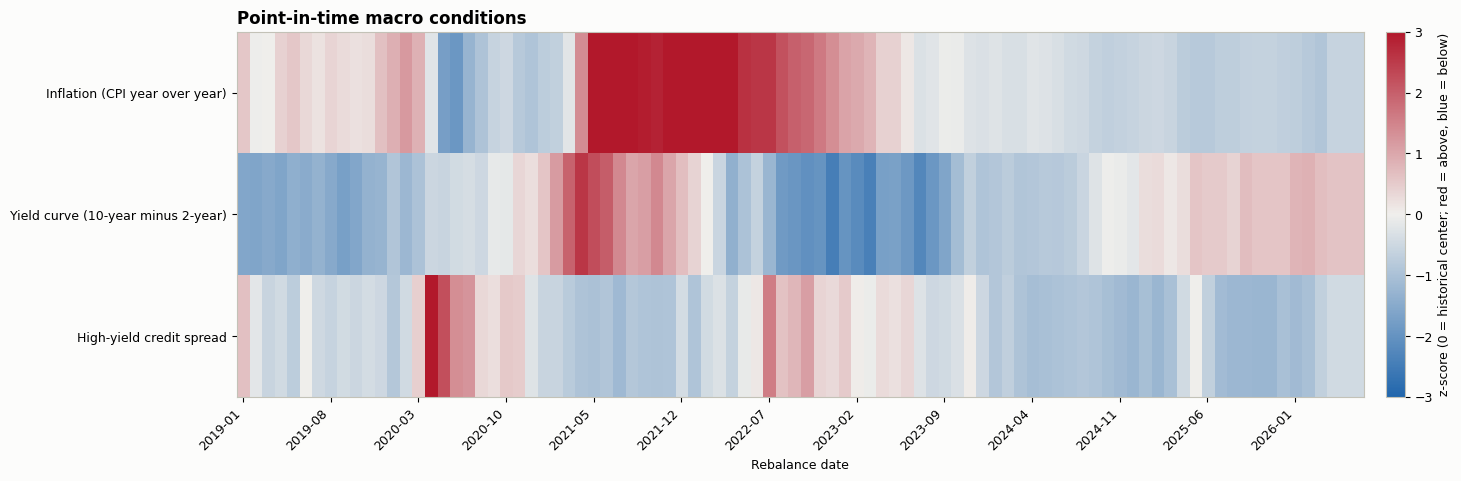

### Reading this heatmap
Red means the macro reading is above its historical center. Blue means it is below. The scale is fixed from -3 to +3 so dates are comparable.

**Table view (CVD/print-safe signed values): Exact signed z-scores used in the heatmap.**

,Inflation (CPI year over year),Yield curve (10-year minus 2-year),High-yield credit spread
rebalance_date,,,
2019-01-02,0.554160,-1.587155,0.647656
2019-02-01,-0.030215,-1.599329,-0.184495
2019-03-01,-0.002193,-1.516198,-0.575828
2019-04-01,0.407359,-1.605804,-0.468458
2019-05-01,0.541341,-1.401603,-0.746604
...,...,...,...
2026-02-02,-0.810077,0.857384,-1.007900
2026-03-02,-0.902949,0.666889,-0.666955
2026-04-01,-0.600918,0.595670,-0.446885


In [3]:
macro_columns = ("cpi_yoy_z", "t10y2y_z", "hy_oas_z")
missing_macro = [name for name in macro_columns if name not in guarded.columns]
if missing_macro:
    raise ValueError(f"Canonical panel missing required macro axes: {missing_macro}")
macro_norm_col = require_column(guarded, ("macro_state_norm", "macro_z_norm"), "macro-to-BL panel")
for name in (*macro_columns, macro_norm_col):
    per_date_unique = guarded.groupby(date_col)[name].nunique(dropna=False)
    if (per_date_unique > 1).any():
        raise ValueError(f"Canonical macro field {name} conflicts across assets on a date")
macro_by_date = guarded[[date_col, *macro_columns, macro_norm_col]].drop_duplicates(date_col).sort_values(date_col)
macro_matrix = macro_by_date.set_index(date_col)[list(macro_columns)].T

fig, ax = plt.subplots(figsize=(14.5, 4.7), constrained_layout=True)
image = ax.imshow(macro_matrix.to_numpy(dtype=float), aspect="auto", interpolation="nearest",
                  cmap=DIVERGING_CMAP, vmin=-MACRO_Z_LIMIT, vmax=MACRO_Z_LIMIT)
ax.set_yticks(range(len(macro_columns)), labels=[MACRO_LABELS[name] for name in macro_columns])
step = max(1, len(macro_matrix.columns) // 12)
xticks = np.arange(0, len(macro_matrix.columns), step)
ax.set_xticks(xticks, labels=[macro_matrix.columns[i].strftime("%Y-%m") for i in xticks], rotation=45, ha="right")
ax.set_title("Point-in-time macro conditions", loc="left", fontweight="semibold")
ax.set_xlabel("Rebalance date")
colorbar = fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
colorbar.set_label("z-score (0 = historical center; red = above, blue = below)")
fig.savefig(OUTPUT_DIR / "appendix_f_macro_state_heatmap.png", dpi=180, bbox_inches="tight", facecolor=SURFACE)
plt.show()
display(Markdown("### Reading this heatmap\nRed means the macro reading is above its historical center. Blue means it is below. The scale is fixed from -3 to +3 so dates are comparable."))
display(Markdown("**Table view (CVD/print-safe signed values): Exact signed z-scores used in the heatmap.**"))
display(macro_by_date.set_index(date_col)[list(macro_columns)].rename(columns=MACRO_LABELS))


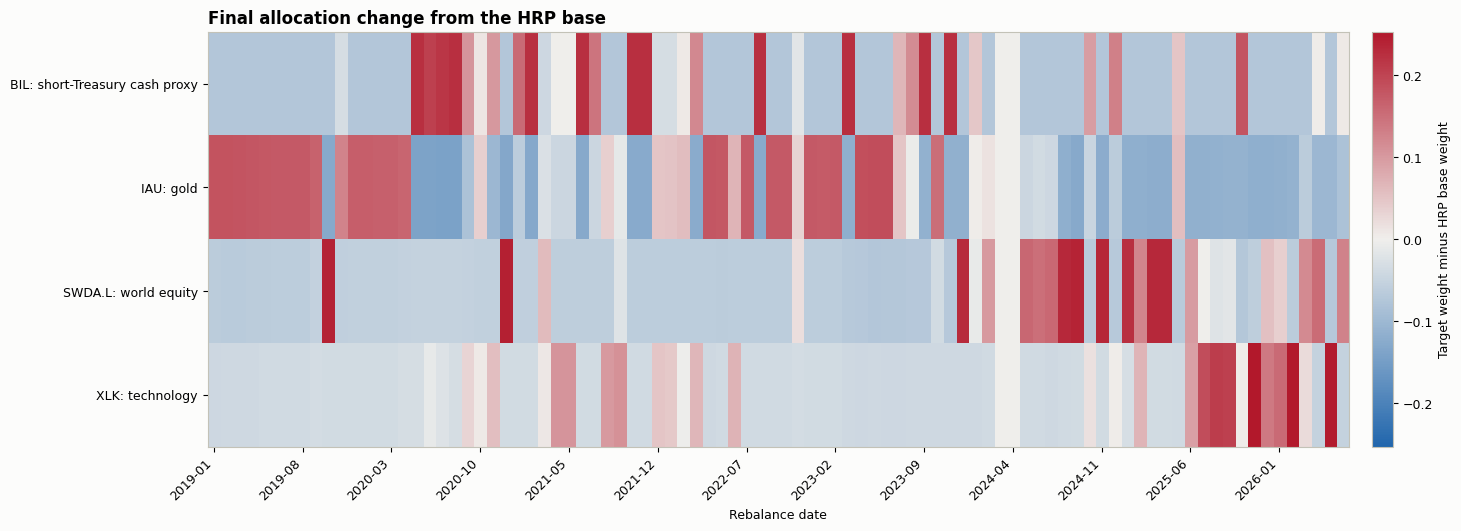

### Reading this heatmap
Each cell is the final target weight minus the HRP base weight. Positive values add weight; negative values remove weight.

**Table view (CVD/print-safe signed values): Exact portfolio-weight changes shown in the heatmap.**

asset_id,BIL: short-Treasury cash proxy,IAU: gold,SWDA.L: world equity,XLK: technology
rebalance_date,,,,
2019-01-02,-0.075000,0.181807,-0.064823,-0.041984
2019-02-01,-0.075000,0.181676,-0.066448,-0.040228
2019-03-01,-0.075000,0.180623,-0.065512,-0.040112
2019-04-01,-0.075000,0.178833,-0.064157,-0.039676
2019-05-01,-0.075000,0.177493,-0.063600,-0.038893
...,...,...,...,...
2026-02-02,-0.075000,-0.111227,-0.064155,0.250382
2026-03-02,-0.075000,-0.064529,0.117779,0.021750
2026-04-01,0.002132,-0.101770,0.152318,-0.052680


In [4]:
target_delta_col = require_column(guarded, ("target_delta", "persisted_target_delta"), "macro-to-BL panel")
if guarded.duplicated([date_col, asset_col]).any():
    raise ValueError("Canonical panel requires one guarded-PIT row per date/asset")
target_matrix = guarded.pivot(index=asset_col, columns=date_col, values=target_delta_col).sort_index()
if target_matrix.empty or not np.isfinite(target_matrix.to_numpy(dtype=float)).all():
    raise ValueError("Persisted target_delta heatmap requires a complete finite asset/date matrix")
target_delta_limit = float(np.nanmax(np.abs(target_matrix.to_numpy(dtype=float))))
if not np.isfinite(target_delta_limit) or target_delta_limit <= 0:
    raise ValueError("target_delta heatmap requires a positive symmetric plotting limit")

fig, ax = plt.subplots(figsize=(14.5, 5.2), constrained_layout=True)
image = ax.imshow(target_matrix.to_numpy(dtype=float), aspect="auto", interpolation="nearest",
                  cmap=DIVERGING_CMAP, vmin=-target_delta_limit, vmax=target_delta_limit)
ax.set_yticks(range(len(target_matrix.index)), labels=[ASSET_LABELS[name] for name in target_matrix.index])
step = max(1, len(target_matrix.columns) // 12)
xticks = np.arange(0, len(target_matrix.columns), step)
ax.set_xticks(xticks, labels=[target_matrix.columns[i].strftime("%Y-%m") for i in xticks], rotation=45, ha="right")
ax.set_title("Final allocation change from the HRP base", loc="left", fontweight="semibold")
ax.set_xlabel("Rebalance date")
colorbar = fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
colorbar.set_label("Target weight minus HRP base weight")
fig.savefig(OUTPUT_DIR / "appendix_f_target_delta_heatmap.png", dpi=180, bbox_inches="tight", facecolor=SURFACE)
plt.show()
display(Markdown("### Reading this heatmap\nEach cell is the final target weight minus the HRP base weight. Positive values add weight; negative values remove weight."))
display(Markdown("**Table view (CVD/print-safe signed values): Exact portfolio-weight changes shown in the heatmap.**"))
display(target_matrix.T.rename(columns=ASSET_LABELS))


### Reading the scatterplots
Each point is one rebalance date. Moving right means the macro measure is higher relative to its historical center. Moving up means the asset weight is higher than its HRP base weight. The lines mark zero.

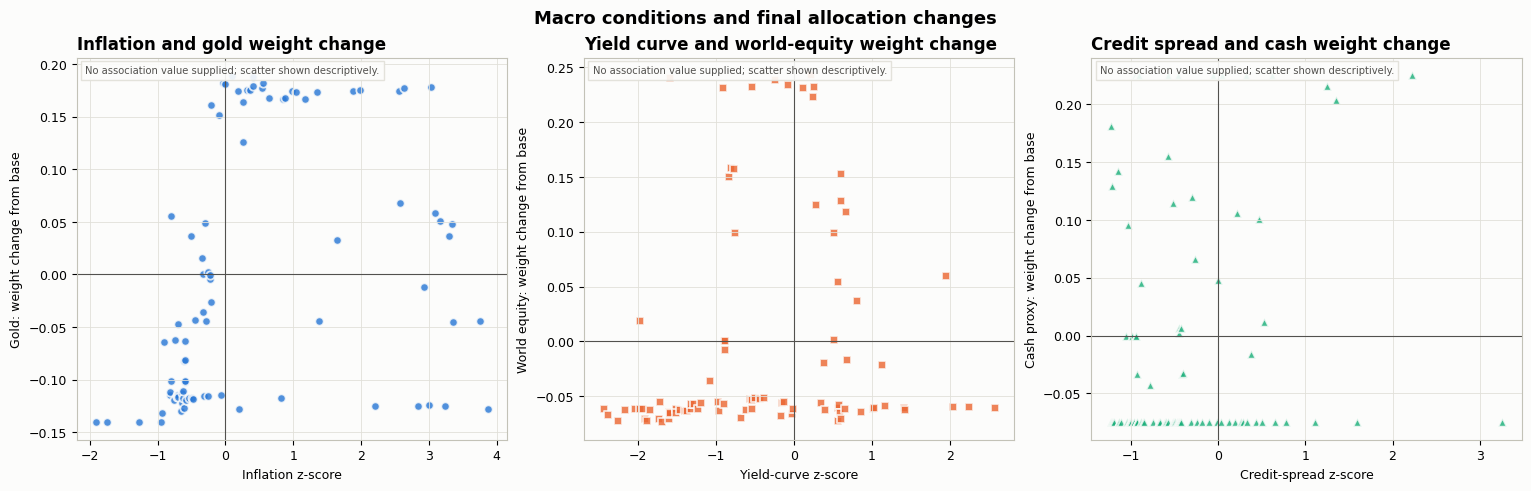

In [5]:
association_candidates = (
    "model_implied_contemporaneous_association",
    "canonical_contemporaneous_association",
    "association_value",
)
association_col = next((name for name in association_candidates if name in guarded.columns), None)

display(Markdown("### Reading the scatterplots\nEach point is one rebalance date. Moving right means the macro measure is higher relative to its historical center. Moving up means the asset weight is higher than its HRP base weight. The lines mark zero."))
fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.8), constrained_layout=True)
for ax, (macro_axis, asset_id, title) in zip(axes, PRESPECIFIED_MACRO_ASSET_PAIRS, strict=True):
    rows = guarded.loc[guarded[asset_col].astype(str) == asset_id].sort_values(macro_axis)
    if rows.empty:
        raise ValueError(f"Prespecified asset {asset_id} is absent for {macro_axis}")
    color = ASSET_COLORS[asset_id]
    marker = ASSET_MARKERS[asset_id]
    ax.scatter(rows[macro_axis], rows[target_delta_col], color=color, marker=marker, s=36,
               edgecolor=SURFACE, linewidth=1.3, alpha=0.82)
    ax.axhline(0.0, color=SECONDARY, linewidth=0.8)
    ax.axvline(0.0, color=SECONDARY, linewidth=0.8)
    ax.grid(True)
    ax.set_title(title, loc="left", fontweight="semibold")
    axis_labels = {
        "cpi_yoy_z": "Inflation z-score",
        "t10y2y_z": "Yield-curve z-score",
        "hy_oas_z": "Credit-spread z-score",
    }
    asset_axis_labels = {
        "IAU": "Gold: weight change from base",
        "SWDA.L": "World equity: weight change from base",
        "BIL": "Cash proxy: weight change from base",
    }
    ax.set_xlabel(axis_labels[macro_axis])
    ax.set_ylabel(asset_axis_labels[asset_id])
    if association_col is not None:
        supplied = rows[association_col].dropna().unique()
        if len(supplied) > 1:
            raise ValueError(f"Producer supplied conflicting association values for {macro_axis}/{asset_id}")
        note = f"Model-implied contemporaneous association: {supplied[0]:.3f}\nNon-causal; producer-supplied." if len(supplied) == 1 else "No association value supplied."
    else:
        note = "No association value supplied; scatter shown descriptively."
    ax.text(0.02, 0.98, note, transform=ax.transAxes, fontsize=7.2, color=SECONDARY,
            va="top", bbox={"facecolor": SURFACE, "edgecolor": GRID, "alpha": 0.92, "pad": 3})
fig.suptitle("Macro conditions and final allocation changes", fontsize=13, fontweight="semibold")
fig.savefig(OUTPUT_DIR / "appendix_f_macro_tilt_links.png", dpi=180, bbox_inches="tight", facecolor=SURFACE)
plt.show()

## Worked dates selected from macro conditions, not returns

The first date is farthest from neutral across the three macro z-scores. The second is closest. Loadings and exposure tilts are unitless; the final weight change is a portfolio-weight difference.

,Why this date,Rebalance date,Asset,Inflation z-score,10-year minus 2-year z-score,High-yield spread z-score,Distance from neutral,Inflation loading,Growth loading,Credit-stress loading,Policy loading,Risk-appetite loading,Raw exposure tilt (unitless),Guarded exposure tilt (unitless),BL view input,Weight change from HRP base
0,Macro state closest to neutral,2020-09-01,BIL,-0.603016,-0.135516,0.219047,0.655724,-0.6,-0.14,0.22,-0.1,-0.3,0.136,0.132566,0.000171,0.105980
1,Macro state closest to neutral,2020-09-01,IAU,-0.603016,-0.135516,0.219047,0.655724,-0.6,-0.14,0.22,-0.1,-0.3,-0.130,-0.126717,-0.000163,-0.082584
2,Macro state closest to neutral,2020-09-01,SWDA.L,-0.603016,-0.135516,0.219047,0.655724,-0.6,-0.14,0.22,-0.1,-0.3,-0.286,-0.278777,-0.000359,-0.054818
3,Macro state closest to neutral,2020-09-01,XLK,-0.603016,-0.135516,0.219047,0.655724,-0.6,-0.14,0.22,-0.1,-0.3,-0.124,-0.120869,-0.000156,0.031422
4,Most unusual macro state,2021-06-01,BIL,3.865504,2.035544,-0.904974,4.461451,0.9,-0.40,0.50,0.8,-0.6,1.810,1.697283,0.004488,0.224996
5,Most unusual macro state,2021-06-01,IAU,3.865504,2.035544,-0.904974,4.461451,0.9,-0.40,0.50,0.8,-0.6,1.610,1.509738,0.003992,-0.127982
6,Most unusual macro state,2021-06-01,SWDA.L,3.865504,2.035544,-0.904974,4.461451,0.9,-0.40,0.50,0.8,-0.6,-1.670,-1.566002,-0.004141,-0.060132
7,Most unusual macro state,2021-06-01,XLK,3.865504,2.035544,-0.904974,4.461451,0.9,-0.40,0.50,0.8,-0.6,-2.170,-2.034865,-0.005381,-0.036882


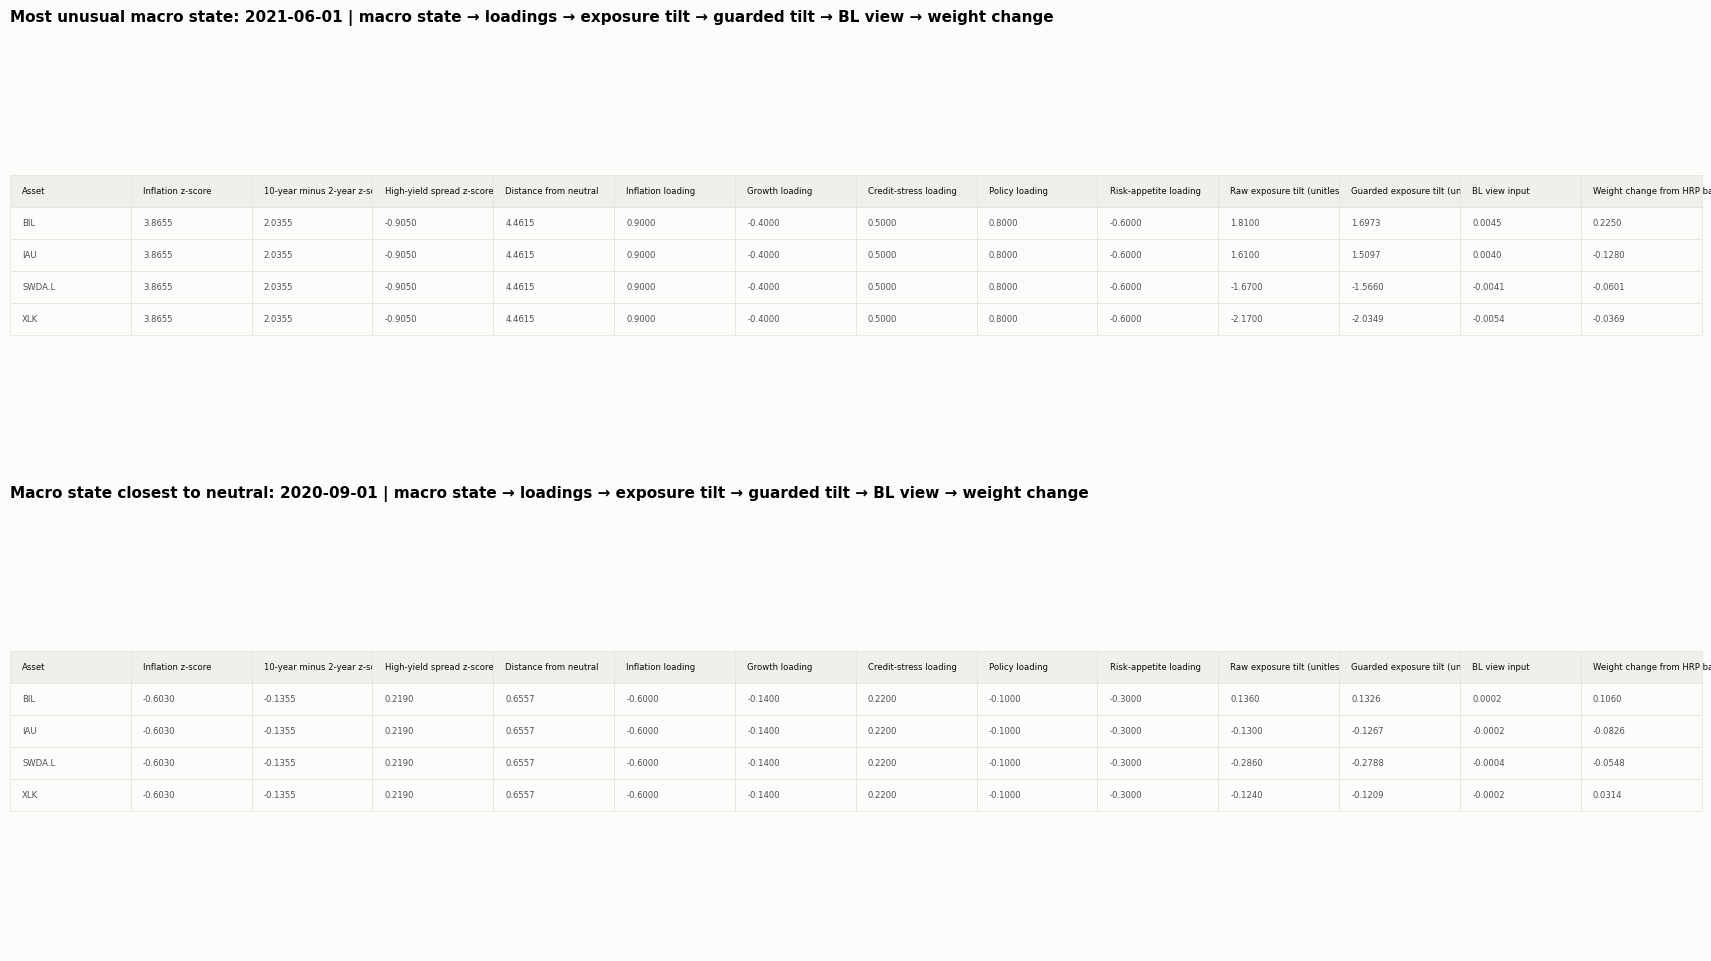

In [6]:
loading_columns = (
    "loading_inflation",
    "loading_growth",
    "loading_credit_stress",
    "loading_policy",
    "loading_risk_appetite",
)
missing_loadings = [name for name in loading_columns if name not in guarded.columns]
if missing_loadings:
    raise ValueError(f"Canonical panel missing parsed loading fields: {missing_loadings}")
raw_tilt_col = require_column(guarded, ("raw_tilt", "raw_expected_excess_annualized"), "worked-date panel")
applied_tilt_col = require_column(guarded, ("applied_tilt", "guarded_tilt", "applied_expected_excess_annualized"), "worked-date panel")
bl_q_col = require_column(guarded, ("bl_q", "Q", "bl_view_q"), "worked-date panel")

# Prespecified worked-date rule: producer-owned macro-state norm only, never returns.
norm_by_date = macro_by_date.set_index(date_col)[macro_norm_col]
max_state_date = pd.Timestamp(norm_by_date.idxmax())
nearest_neutral_date = pd.Timestamp(norm_by_date.idxmin())
if max_state_date == nearest_neutral_date:
    raise ValueError("Worked-date selectors must produce two distinct dates")
# Canonical selectors: maximum macro-state norm and nearest-neutral macro-state norm.
selection_roles = {max_state_date: "Most unusual macro state", nearest_neutral_date: "Macro state closest to neutral"}
worked = guarded.loc[guarded[date_col].isin(selection_roles)].copy()
worked["worked_date_role"] = worked[date_col].map(selection_roles)
worked_columns = [
    "worked_date_role", date_col, asset_col, *macro_columns, macro_norm_col,
    *loading_columns, raw_tilt_col, applied_tilt_col, bl_q_col, target_delta_col,
]
worked_table = worked[worked_columns].sort_values([date_col, asset_col]).reset_index(drop=True)
worked_labels = {
    "worked_date_role": "Why this date", date_col: "Rebalance date", asset_col: "Asset",
    "cpi_yoy_z": "Inflation z-score", "t10y2y_z": "10-year minus 2-year z-score", "hy_oas_z": "High-yield spread z-score",
    macro_norm_col: "Distance from neutral", "loading_inflation": "Inflation loading", "loading_growth": "Growth loading",
    "loading_credit_stress": "Credit-stress loading", "loading_policy": "Policy loading", "loading_risk_appetite": "Risk-appetite loading",
    raw_tilt_col: "Raw exposure tilt (unitless)", applied_tilt_col: "Guarded exposure tilt (unitless)",
    bl_q_col: "BL view input", target_delta_col: "Weight change from HRP base",
}
display(Markdown("## Worked dates selected from macro conditions, not returns"))
display(Markdown("The first date is farthest from neutral across the three macro z-scores. The second is closest. Loadings and exposure tilts are unitless; the final weight change is a portfolio-weight difference."))
display(worked_table.rename(columns=worked_labels))

fig, axes = plt.subplots(2, 1, figsize=(17, 9.5), constrained_layout=True)
for ax, selected_date in zip(axes, (max_state_date, nearest_neutral_date), strict=True):
    shown = worked_table.loc[worked_table[date_col] == selected_date].drop(columns=["worked_date_role", date_col]).copy().rename(columns=worked_labels)
    shown = shown.apply(lambda col: col.map(lambda value: "" if pd.isna(value) else f"{value:.4f}" if isinstance(value, (float, np.floating)) else str(value)))
    ax.axis("off")
    ax.set_title(f"{selection_roles[selected_date]}: {selected_date.date()} | macro state → loadings → exposure tilt → guarded tilt → BL view → weight change",
                 loc="left", fontsize=11, fontweight="semibold", pad=10)
    table = ax.table(cellText=shown.values, colLabels=shown.columns, loc="center", cellLoc="left", colLoc="left")
    table.auto_set_font_size(False)
    table.set_fontsize(6.1)
    table.scale(1.0, 1.45)
    for (row, _), cell in table.get_celld().items():
        cell.set_edgecolor(GRID)
        cell.set_linewidth(0.45)
        cell.set_facecolor("#f0efec" if row == 0 else SURFACE)
        cell.get_text().set_color(INK if row == 0 else SECONDARY)
fig.savefig(OUTPUT_DIR / "appendix_f_worked_dates.png", dpi=180, bbox_inches="tight", facecolor=SURFACE)
plt.show()


## Why the steps do not have the same size

A macro loading is not a portfolio weight. It passes through several steps before it becomes a final allocation change:

1. the **exposure map** turns macro loadings into asset-specific raw exposure tilts;
2. **conviction** scales those views;
3. **recall attenuation** reduces a view when the prompt may recall known history;
4. **BL conversion** turns the guarded view into a Black-Litterman input and allocation response; and
5. the **HRP/BL blend** combines that response with the base portfolio.

These quantities use different units. The loading and exposure tilt are unitless, the Black-Litterman input is scaled by conviction and time, and the final weight change comes after the allocation blend. The scatterplots are model-implied contemporaneous associations, not causal effects. The notebook shows an association value only when the producer supplied it; it does not calculate correlations or regressions.

In [7]:
F_FIGURES = (
    "appendix_f_macro_state_heatmap.png",
    "appendix_f_target_delta_heatmap.png",
    "appendix_f_macro_tilt_links.png",
    "appendix_f_worked_dates.png",
)
assert_sources_unchanged(
    REPO_ROOT, BUNDLE_DIR, SOURCE_RUN_DIR, source_inventory, bundle_manifest, source_hashes_before
)
presentation_manifest_path = write_presentation_manifest(
    repo_root=REPO_ROOT,
    notebook_path=NOTEBOOK_PATH,
    output_dir=OUTPUT_DIR,
    schema="appendix_f_macro_to_bl_tilt.presentation.v1",
    appendix_id="appendix_f_macro_to_bl_tilt",
    bundle_dir=BUNDLE_DIR,
    bundle_manifest=bundle_manifest,
    bundle_manifest_sha=bundle_manifest_sha,
    source_inventory=source_inventory,
    source_child_run=source_child_run,
    figure_names=F_FIGURES,
)
assert_sources_unchanged(
    REPO_ROOT, BUNDLE_DIR, SOURCE_RUN_DIR, source_inventory, bundle_manifest, source_hashes_before
)
display(Markdown(markdown_lines([
    f"**Appendix F presentation manifest:** `{presentation_manifest_path}`",
    f"SHA-256: `{sha256_file(presentation_manifest_path)}`",
])))

**Appendix F presentation manifest:** `/home/mc/projects/Global_Macro_AI_Factors/reports/appendix_f_macro_to_bl_tilt/presentation_manifest.json`  
SHA-256: `73312e9f449e752645d736c4352ed2be958d4f1a594f8fdb409fc9a9290d2da4`